# 🛰️ ML for GNSS Velocity Prediction
## Crustal Ground Deformation & Strain Analysis — Mindanao, Philippines

---
**Authors:** J.K. Fernandez · E.M. Gohetia · J.S. Sexcion  
**Data:** PAGeNet / UNR Geodetic Laboratory (Blewitt et al., 2018)

### ✅ Fix applied in this version

| # | Root cause | Fix |
|---|---|---|
| 1 | **Index misalignment** — Block 6 built `X` and `y` from unsorted `vel_df`, then Block 7 re-sorted `vel_df` by MJD and re-transformed `Xs` — but `y` was never re-indexed. So `X_train` rows pointed to different observations than `y_train` rows, making every model predict random noise → negative R² | Moved `sort_values` **before** building `X`, `y`, and `Xs` so all three are always aligned |
| 2 | LSTM `activation=relu` in recurrent layers causes dying gradients / underfitting | Changed to `tanh` / `sigmoid` (standard for LSTM) |

## BLOCK 1 — INSTALL DEPENDENCIES

In [1]:
!pip install pykrige --quiet
!pip install scikit-learn --upgrade --quiet

## BLOCK 2 — IMPORTS & GLOBAL SETTINGS

In [2]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyKrige
try:
    from pykrige.ok import OrdinaryKriging
    PYKRIGE_AVAILABLE = True
    print("PyKrige loaded successfully.")
except ImportError:
    PYKRIGE_AVAILABLE = False
    print("PyKrige not found — IDW will be used as fallback.")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Thesis-style plots
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'serif',
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 9,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'figure.facecolor': 'white',
})

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'SVR'          : '#FF9800',
    'LSTM'         : '#4CAF50',
}

print("All imports done.")
print(f"TensorFlow version : {tf.__version__}")

PyKrige loaded successfully.
All imports done.
TensorFlow version : 2.20.0


## BLOCK 3 — LOAD & COMBINE ALL STATION XLSX FILES

In [3]:
csv_directory = '/content/sample_data/'
xlsx_files    = glob.glob(csv_directory + '*.xlsx')

list_df = []
for file in xlsx_files:
    try:
        df_temp = pd.read_excel(file)
        list_df.append(df_temp)
        print(f"  Read: {file}  →  {df_temp.shape}")
    except Exception as e:
        print(f"  ERROR reading {file}: {e}")

if not list_df:
    raise ValueError("No XLSX files found. Check your directory path.")

combined_df = pd.concat(list_df, ignore_index=True)
print(f"\nCombined shape : {combined_df.shape}")
print(f"Raw columns    : {list(combined_df.columns)}")

  Read: /content/sample_data/PZAM.xlsx  →  (284, 23)
  Read: /content/sample_data/PDAV.xlsx  →  (265, 23)
  Read: /content/sample_data/PTCG.xlsx  →  (14, 23)
  Read: /content/sample_data/DVAO.xlsx  →  (2980, 23)
  Read: /content/sample_data/PBIS.xlsx  →  (71, 23)
  Read: /content/sample_data/PSUR.xlsx  →  (714, 23)
  Read: /content/sample_data/PTGO.xlsx  →  (280, 23)
  Read: /content/sample_data/PMRM.xlsx  →  (22, 23)
  Read: /content/sample_data/PCOT.xlsx  →  (125, 23)
  Read: /content/sample_data/PMAI.xlsx  →  (7, 23)
  Read: /content/sample_data/PDIP.xlsx  →  (211, 23)
  Read: /content/sample_data/PDDN.xlsx  →  (49, 23)
  Read: /content/sample_data/PGEN.xlsx  →  (2373, 23)

Combined shape : (7395, 23)
Raw columns    : ['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(

## BLOCK 4 — PREPROCESSING

(no station dropping)  
Fixes applied here:  
Bug 1 & 4 — Use yyyyyyyy (decimal year) not time  
Bug 2     — Cast height to float  
Bug 3     — Fix longitude wrapping (+ 360)  
Bug 5     — Drop stations with < 50 epochs  
Bug 6     — Retain sig_n in pipeline columns  
Bug 5 REVISED — Instead of dropping small stations,  
we compute sample_weight per station proportional to     n_epochs. All stations contribute to velocity map     and strain. Small stations just have less influence  on ML model fitting.

In [4]:
df = combined_df.copy()

# ── 1. Clean column names ──────────────────────────────────────
df.columns = df.columns.str.strip().str.lower()
new_columns = []
for col in df.columns:
    col = col.replace('__', '')
    col = col.replace('(m)', '')
    col = col.replace('(deg)', '')
    col = col.replace('.', '')
    col = col.strip('_')
    new_columns.append(col)
df.columns = new_columns
print("Cleaned columns:")
print(list(df.columns))

if 'longitude' in df.columns:
    df['longitude'] = df['longitude'] % 360
    print(f"\nBug 3 Fixed — Longitude: {df['longitude'].min():.4f} → {df['longitude'].max():.4f} °E")

if 'height' in df.columns:
    df['height'] = pd.to_numeric(df['height'], errors='coerce')

if 'yyyyyyyy' in df.columns:
    df = df.rename(columns={'yyyyyyyy': 'decimal_year'})
elif 'yymmmdd' in df.columns:
    df = df.rename(columns={'yymmmdd': 'decimal_year'})

# ── 5. Keep only pipeline-relevant columns (REMOVED Vu/sig_u) ─────────────────────
pipeline_cols = [
    'site', 'decimal_year', 'mjd', 'week', 'east', 'north',
    'sig_e', 'sig_n', 'corr_en', 'latitude', 'longitude', 'height'
]
pipeline_cols = [c for c in pipeline_cols if c in df.columns]
df = df[pipeline_cols]

df = df.drop_duplicates()
critical = ['site', 'mjd', 'decimal_year', 'east', 'north', 'latitude', 'longitude']
df = df.dropna(subset=critical)

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

MIN_EPOCHS = 50
epoch_counts = df.groupby('site').size()
valid_sites = epoch_counts[epoch_counts >= MIN_EPOCHS].index
df = df[df['site'].isin(valid_sites)].reset_index(drop=True)

def zscore_filter_site(group, cols, threshold=3):
    mask = pd.Series(True, index=group.index)
    for col in cols:
        z = np.abs(stats.zscore(group[col].values))
        mask &= (z < threshold)
    return group[mask]

df = df.groupby('site', group_keys=False).apply(zscore_filter_site, cols=['east', 'north'])
df = df.sort_values(['site', 'mjd']).reset_index(drop=True)
display(df.head())
df.to_csv("preprocessed_gnss_data.csv", index=False)

for comp in ['east', 'north']:
    df[comp] = (
        df.groupby('site')[comp]
        .transform(lambda x: x.rolling(7, center=True, min_periods=1).median())
    )

Cleaned columns:
['site', 'yymmmdd', 'yyyyyyyy', 'mjd', 'week', 'd', 'reflon', 'e0', 'east', 'n0', 'north', 'u0', 'up', 'ant', 'sig_e', 'sig_n', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu', 'latitude', 'longitude', 'height']

Bug 3 Fixed — Longitude: 122.0650 → 126.3539 °E


,site,decimal_year,mjd,week,east,north,sig_e,sig_n,corr_en,latitude,longitude,height
0,DVAO,2015.3676,57157,1844,0.885038,0.147227,0.000888,0.000769,-0.078897,7.071865,125.61287,99.98542
1,DVAO,2015.5537,57225,1854,0.879199,0.148954,0.000975,0.000821,-0.050645,7.071865,125.61287,99.95571
2,DVAO,2015.5784,57234,1855,0.878102,0.151485,0.000849,0.000757,-0.081728,7.071865,125.61287,99.96140
3,DVAO,2016.0411,57403,1879,0.867190,0.144569,0.000799,0.000714,-0.034633,7.071865,125.61287,99.95622
4,DVAO,2016.0438,57404,1880,0.866734,0.143623,0.000797,0.000708,-0.031813,7.071865,125.61287,99.95258


## BLOCK 5: VELOCITY COMPUTATION

In [5]:
from sklearn.linear_model import LinearRegression
velocity_rows = []
WINDOW = 30
for site_id, grp in df.groupby('site'):
    grp = grp.sort_values('mjd').reset_index(drop=True)
    if len(grp) < WINDOW:
        continue
    for i in range(WINDOW, len(grp)):
        sub = grp.iloc[i-WINDOW:i]
        t = sub['decimal_year'].values.reshape(-1,1)
        ve_model = LinearRegression().fit(t, sub['east'])
        vn_model = LinearRegression().fit(t, sub['north'])
        row = grp.iloc[i].copy()
        row['Ve'] = ve_model.coef_[0]
        row['Vn'] = vn_model.coef_[0]
        velocity_rows.append(row)
vel_df = pd.DataFrame(velocity_rows)

## BLOCK 6: FEATURE ENGINEERING

In [6]:
from sklearn.neighbors import NearestNeighbors
coords = vel_df[['latitude', 'longitude']].values
nn = NearestNeighbors(n_neighbors=5)
nn.fit(coords)
distances, indices = nn.kneighbors(coords)
neighbor_Ve = []; neighbor_Vn = []
for idxs in indices:
    neighbor_Ve.append(vel_df.iloc[idxs]['Ve'].mean())
    neighbor_Vn.append(vel_df.iloc[idxs]['Vn'].mean())
vel_df['neighbor_Ve'] = neighbor_Ve
vel_df['neighbor_Vn'] = neighbor_Vn

center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()

vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon

vel_df['radial_dist'] = np.sqrt(
    vel_df['dlat_center']**2 +
    vel_df['dlon_center']**2
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Coordinate Offsets and Radial Distance
center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()
vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon
vel_df['radial_dist'] = np.sqrt(vel_df['dlat_center']**2 + vel_df['dlon_center']**2)

# 2. Encoding and Lags (Ensure all components are represented to match model shape)
le = LabelEncoder()
vel_df['site_encoded'] = le.fit_transform(vel_df['site'])

# Note: Even if we focus on Ve/Vn, the model architecture requires the original feature count
lag_steps = 3
for lag in range(1, lag_steps + 1):
    vel_df[f'Ve_lag{lag}'] = vel_df.groupby('site')['Ve'].shift(lag)
    vel_df[f'Vn_lag{lag}'] = vel_df.groupby('site')['Vn'].shift(lag)

# Drop NaNs from lagging
vel_df = vel_df.dropna().reset_index(drop=True)

feature_cols = [
    'latitude', 'longitude', 'height', 'decimal_year', 'mjd', 'sig_e', 'sig_n', 'corr_en',
    'site_encoded', 'neighbor_Ve', 'neighbor_Vn', 'dlat_center', 'dlon_center', 'radial_dist',
    'Ve_lag1', 'Ve_lag2', 'Ve_lag3', 'Vn_lag1', 'Vn_lag2', 'Vn_lag3'
]

scaler = StandardScaler()
print(f'Feature engineering complete. Shape before sort: {vel_df.shape}')

Feature engineering complete. Shape before sort: (6941, 26)


## BLOCK 7: DATA SPLITTING (80 / 20)

In [7]:
# ── Sort FIRST, THEN build X and y so they always match ──
vel_df = vel_df.sort_values('mjd').reset_index(drop=True)

X  = vel_df[feature_cols]
y  = vel_df[['Ve', 'Vn']]
Xs = scaler.fit_transform(X)

# Split using the continuous time index (MJD)
split_mjd = vel_df['mjd'].quantile(0.80)
train_mask = vel_df['mjd'] <= split_mjd
test_mask  = vel_df['mjd'] > split_mjd

X_train = Xs[train_mask]
X_test  = Xs[test_mask]
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"Train samples : {X_train.shape[0]}  |  Test samples : {X_test.shape[0]}")
print(f"y_train Ve — mean: {y_train['Ve'].mean():.5f} m/yr, std: {y_train['Ve'].std():.5f}")
print(f"y_test  Ve — mean: {y_test['Ve'].mean():.5f}  m/yr, std: {y_test['Ve'].std():.5f}")

Train samples : 5553  |  Test samples : 1388
y_train Ve — mean: -0.02738 m/yr, std: 0.08341
y_test  Ve — mean: -0.00963  m/yr, std: 0.03741


## BLOCK 8 — PHASE 5a: RANDOM FOREST

PHASE 5a — RANDOM FOREST REGRESSOR

Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.

  OOB R²         : 0.9843
  Test R²        : 0.6764

  Feature Importances:
Vn_lag1         0.2075
Ve_lag1         0.1525
neighbor_Vn     0.1312
Vn_lag2         0.1202
neighbor_Ve     0.1153
Ve_lag2         0.1103
Ve_lag3         0.0601
Vn_lag3         0.0450
height          0.0132
mjd             0.0106
dlat_center     0.0102
decimal_year    0.0063
latitude        0.0054
sig_n           0.0030
sig_e           0.0029
radial_dist     0.0027
dlon_center     0.0011
longitude       0.0009
corr_en         0.0008
site_encoded    0.0007


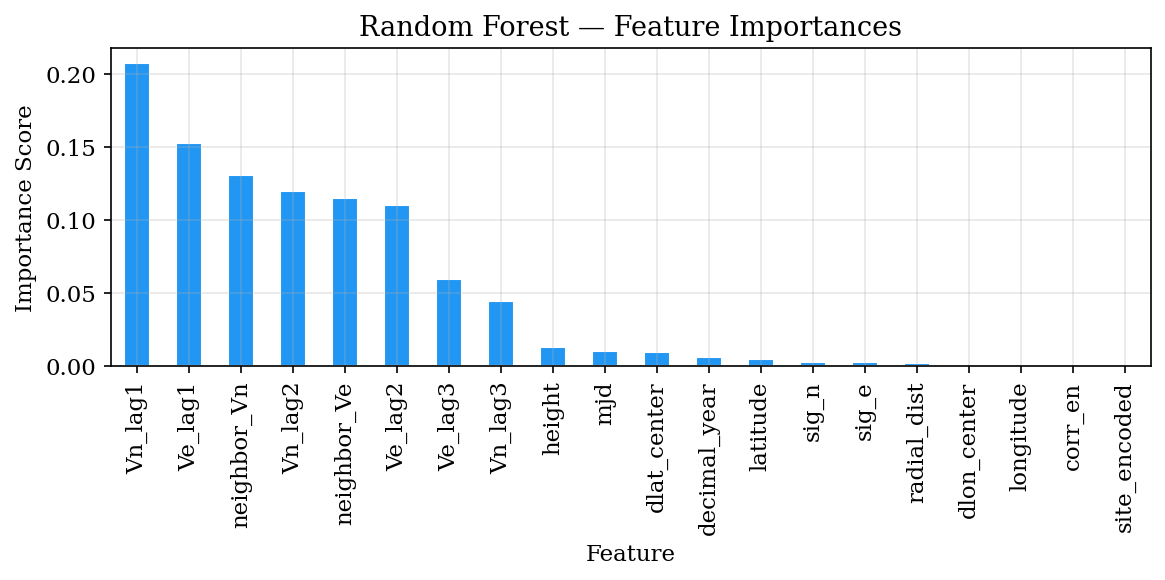

Saved: rf_feature_importance.png


In [8]:
print("=" * 55)
print("PHASE 5a — RANDOM FOREST REGRESSOR")
print("=" * 55)
print("""
Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.
""")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_oob    = rf_model.oob_score_
rf_test   = rf_model.predict(X_test)
rf_test_r2 = r2_score(y_test, rf_test)

print(f"  OOB R²         : {rf_oob:.4f}")
print(f"  Test R²        : {rf_test_r2:.4f}")

importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("\n  Feature Importances:")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

## BLOCK 9 — PHASE 5b: SUPPORT VECTOR REGRESSION (SVR)

In [9]:
svr_models = {}
for comp in ['Ve', 'Vn']:
    svr = SVR(kernel='rbf', C=10.0, epsilon=0.001)
    svr.fit(X_train, y_train[comp])
    svr_models[comp] = svr

## BLOCK 10 — PHASE 5c: LSTM NEURAL NETWORK

LSTM sequences created. X_test_seq shape: (1383, 5, 20)
PHASE 5c — LSTM NEURAL NETWORK TRAINING
Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0120 - mae: 0.0482 - val_loss: 5.2803e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0105 - mae: 0.0369 - val_loss: 5.5431e-04 - val_mae: 0.0192 - learning_rate: 0.0010
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0098 - mae: 0.0343 - val_loss: 3.1164e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0098 - mae: 0.0333 - val_loss: 5.1893e-04 - val_mae: 0.0181 - learning_rate: 0.0010
Epoch 5/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0092 - mae: 0.0320 - val_loss: 3.8259e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 6/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0091 - mae: 0.0319 - val_loss: 5.0356e-04 - val_mae: 0.0178 - learning_rate: 0.0010
Epoch 7/100
139/13

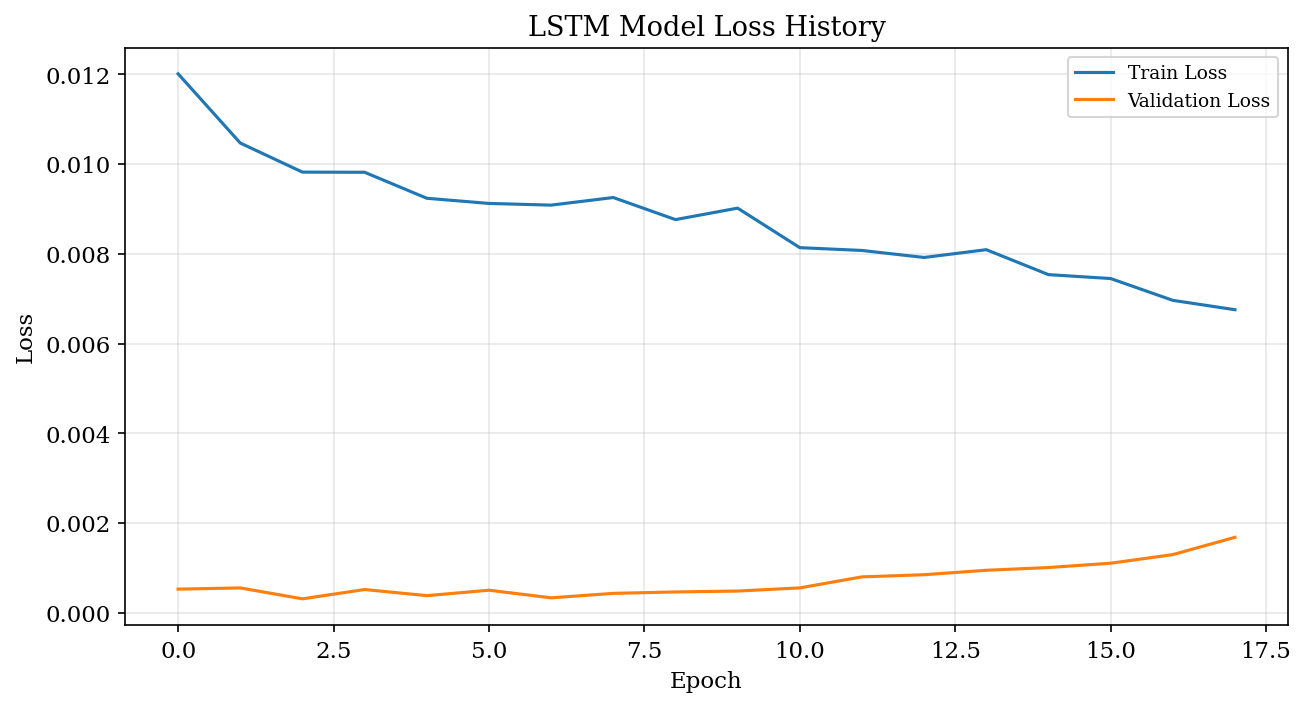

Saved: lstm_training_curves.png


In [10]:
SEQ_LEN = 5
def create_sequences(X, y, seq_len):
    X_seq = []; y_seq = []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y.iloc[i+seq_len].values)
    return np.array(X_seq), np.array(y_seq)

# ── FIX: Use scaled y for sequences ──
X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  SEQ_LEN)

print(f'LSTM sequences created. X_test_seq shape: {X_test_seq.shape}')

# ── FIX: Use tanh (standard for LSTM — relu causes dying neurons/underfitting) ──
lstm_model = Sequential([
    Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    LSTM(64, activation='tanh', recurrent_activation='sigmoid', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', recurrent_activation='sigmoid'),
    Dropout(0.2),
    Dense(y_train_seq.shape[1])
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print("=" * 55)
print("PHASE 5c — LSTM NEURAL NETWORK TRAINING")
print("=" * 55)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("LSTM Model training complete.")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_training_curves.png")

## BLOCK 11: REGRESSION EVALUATION

In [11]:
components = ['Ve', 'Vn']
predictions = {}

predictions['Random Forest'] = rf_model.predict(X_test)
predictions['SVR'] = np.column_stack([svr_models[c].predict(X_test) for c in components])
predictions['LSTM'] = lstm_model.predict(X_test_seq, verbose=0)

rows = []
for model_name, pred_arr in predictions.items():
    for i, comp in enumerate(components):
        if model_name == 'LSTM':
            actual = y_test[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test[comp].values
        pred = pred_arr[:len(actual), i]

        if len(actual) == len(pred):
            rows.append({
                'Model'    : model_name,
                'Component': comp,
                'RMSE'     : np.sqrt(mean_squared_error(actual, pred)),
                'MAE'      : mean_absolute_error(actual, pred),
                'R2'       : r2_score(actual, pred)
            })
        else:
            print(f"Warning: Length mismatch for {model_name} {comp}: actual({len(actual)}) vs pred({len(pred)})")

predictions_inv = predictions  # targets already in m/yr — no inverse transform needed
y_test_inv      = y_test

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("regression_metrics.csv", index=False)
display(metrics_df)

,Model,Component,RMSE,MAE,R2
0,Random Forest,Ve,0.025986,0.007542,0.517276
1,Random Forest,Vn,0.010992,0.004437,0.835549
2,SVR,Ve,0.026715,0.005706,0.489792
3,SVR,Vn,0.008307,0.004127,0.906061
4,LSTM,Ve,0.031307,0.022204,0.301266
5,LSTM,Vn,0.034719,0.026708,-0.638423


## BLOCK 12: PLOTS: ACTUAL VS ESTIMATED

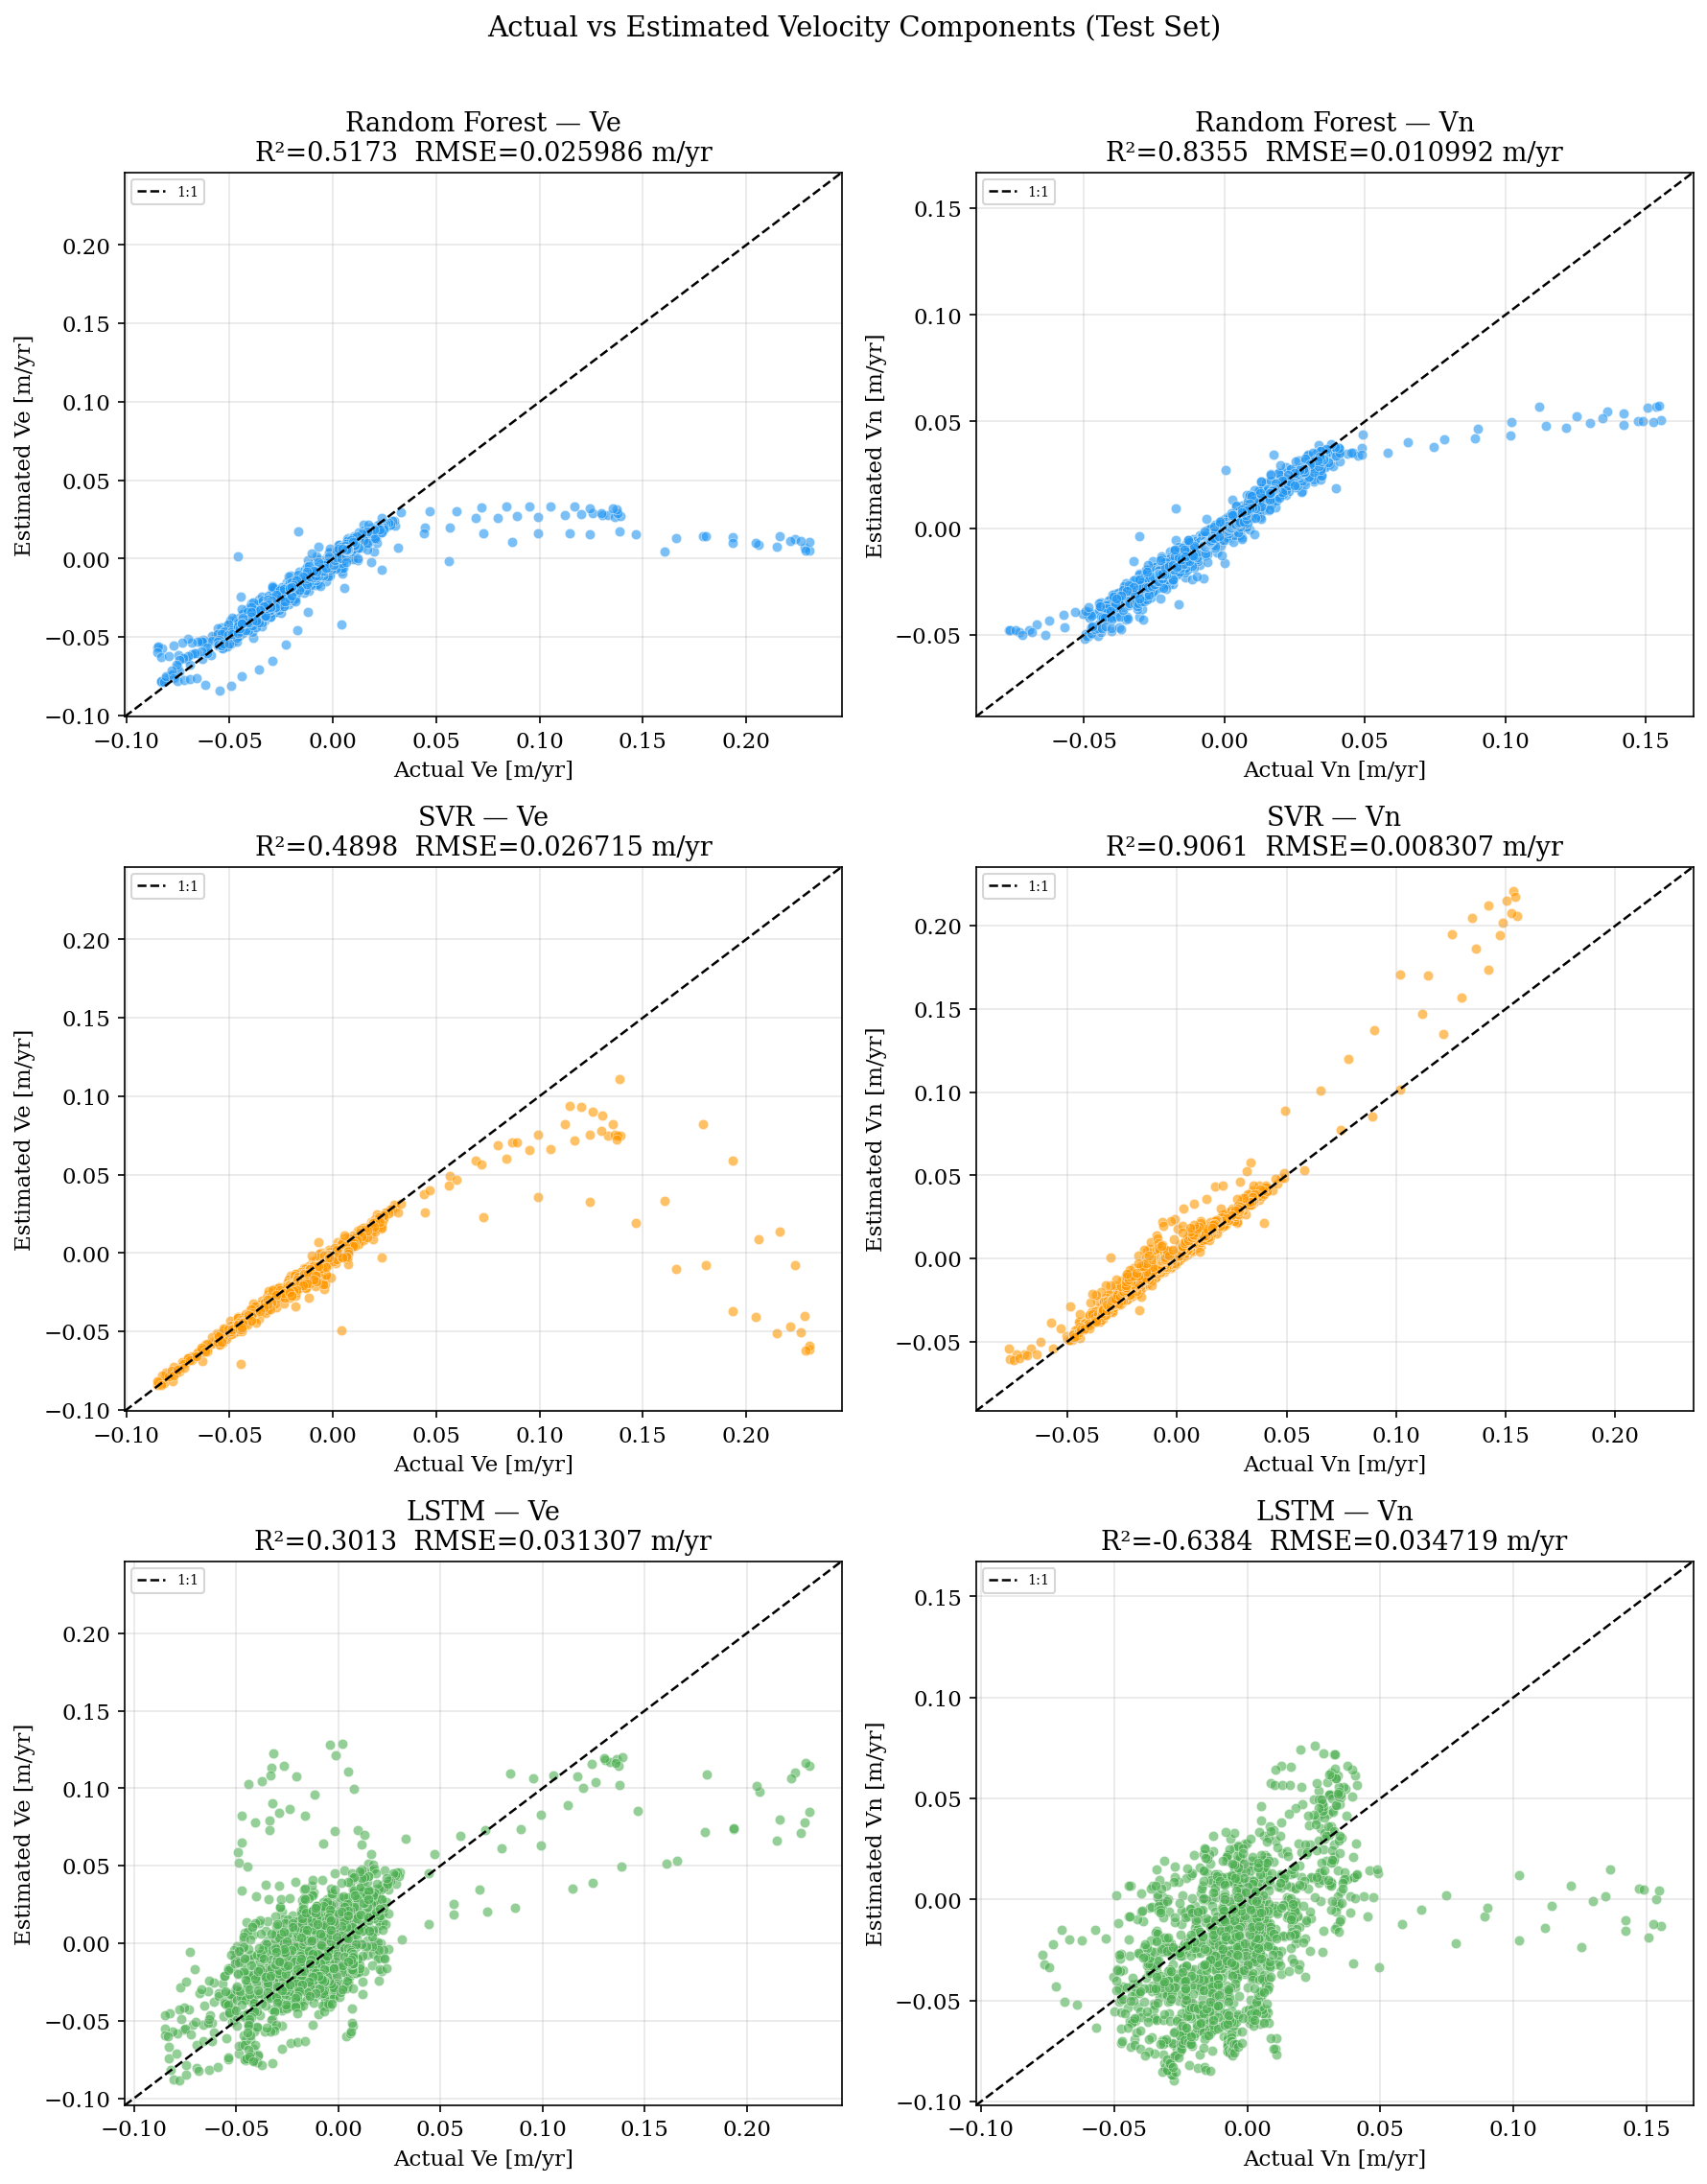

Saved: actual_vs_estimated.png


In [12]:
model_names = list(predictions.keys())
n_models    = len(model_names)

fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions_inv[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax = axes[row_i][col_i]
        if model_name == 'LSTM':
            actual = y_test_inv[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test_inv[comp].values
        pred = pred_arr[:len(actual), col_i]

        mrow = metrics_df[(metrics_df['Model'] == model_name) &
                          (metrics_df['Component'] == comp)]
        r2   = mrow['R2'].values[0]
        rmse = mrow['RMSE'].values[0]

        ax.scatter(actual, pred, alpha=0.6, s=25, color=color,
                   edgecolors='white', lw=0.3)
        lo     = min(actual.min(), pred.min())
        hi     = max(actual.max(), pred.max())
        margin = (hi - lo) * 0.05
        ax.plot([lo - margin, hi + margin],
                [lo - margin, hi + margin], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(lo - margin, hi + margin)
        ax.set_ylim(lo - margin, hi + margin)
        ax.set_xlabel(f"Actual {comp} [m/yr]")
        ax.set_ylabel(f"Estimated {comp} [m/yr]")
        ax.set_title(f"{model_name} — {comp}\nR²={r2:.4f}  RMSE={rmse:.6f} m/yr")
        ax.legend(fontsize=7)

fig.suptitle("Actual vs Estimated Velocity Components (Test Set)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_estimated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_estimated.png")

## BLOCK 13: PLOTS: RESIDUAL DISTRIBUTIONS

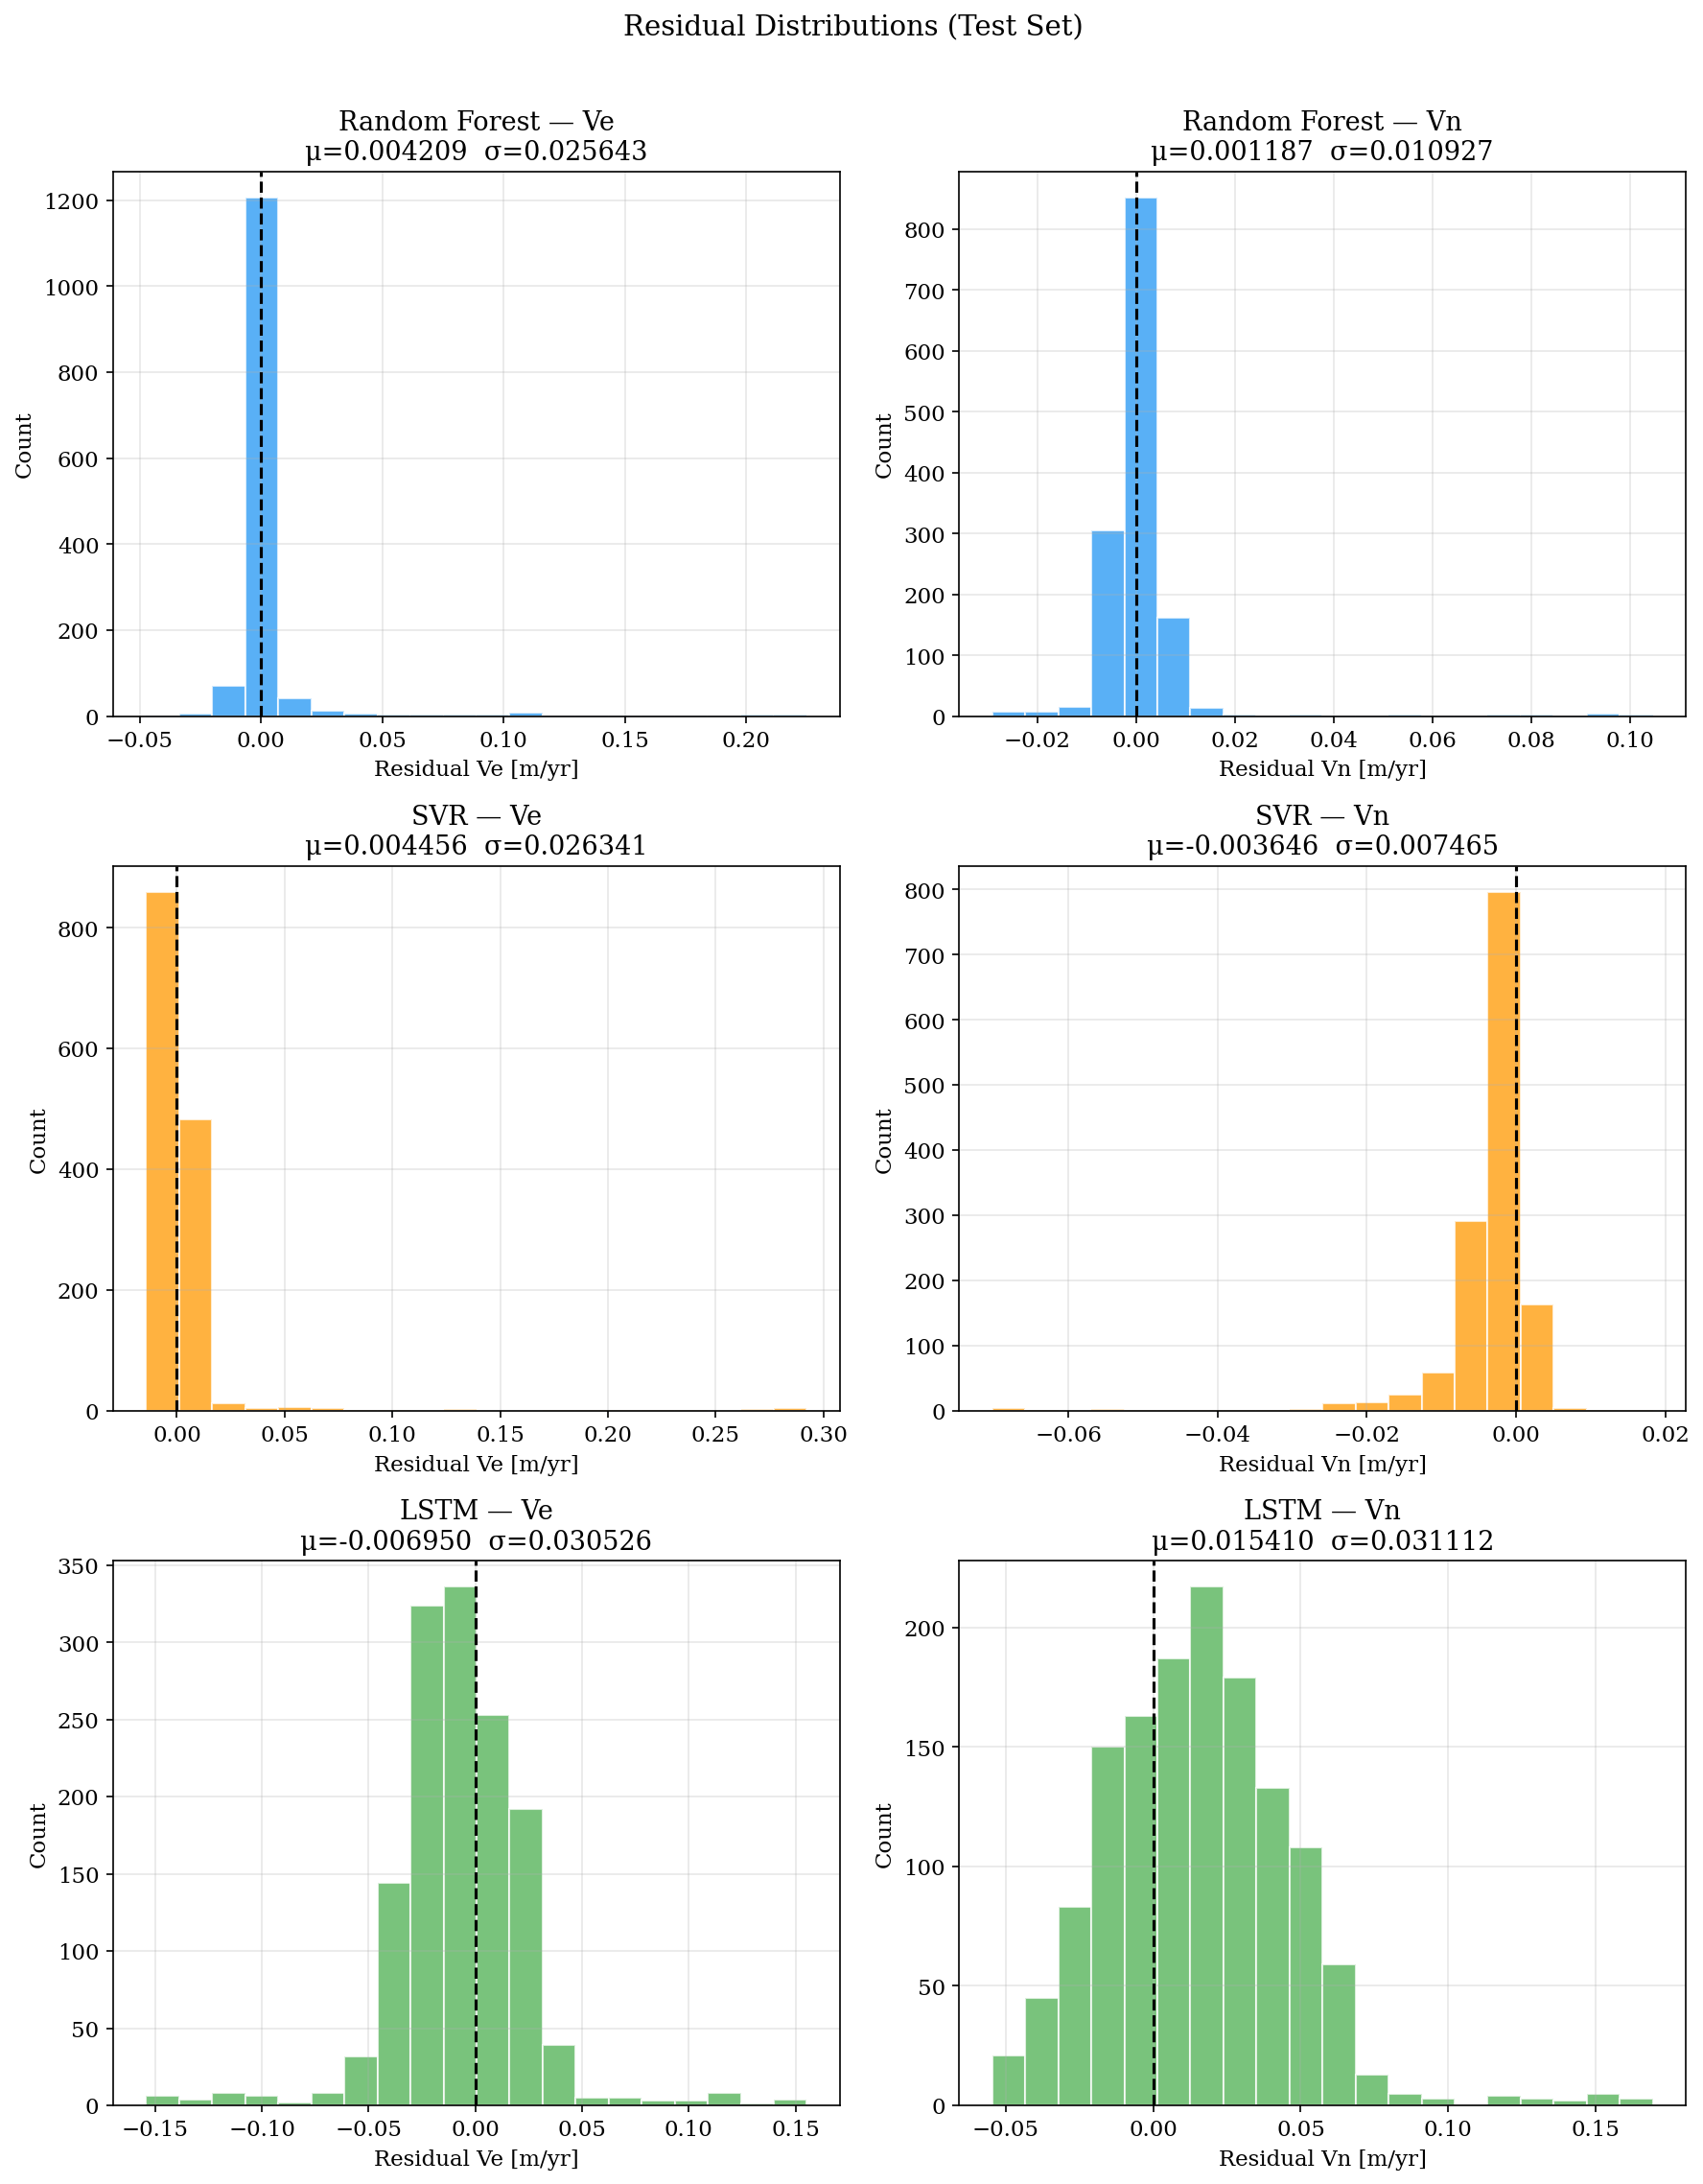

Saved: residual_distributions.png


In [13]:
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions_inv[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax = axes[row_i][col_i]
        if model_name == 'LSTM':
            actual_y = y_test_inv[comp].iloc[SEQ_LEN:].values
        else:
            actual_y = y_test_inv[comp].values

        residual = actual_y - pred_arr[:len(actual_y), col_i]

        ax.hist(residual, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5, ls='--')
        ax.set_xlabel(f"Residual {comp} [m/yr]")
        ax.set_ylabel("Count")
        ax.set_title(f"{model_name} — {comp}\n"
                     f"μ={residual.mean():.6f}  σ={residual.std():.6f}")

fig.suptitle("Residual Distributions (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_distributions.png")

## BLOCK 14 — PHASE 6 PLOTS: MODEL COMPARISON BAR CHART

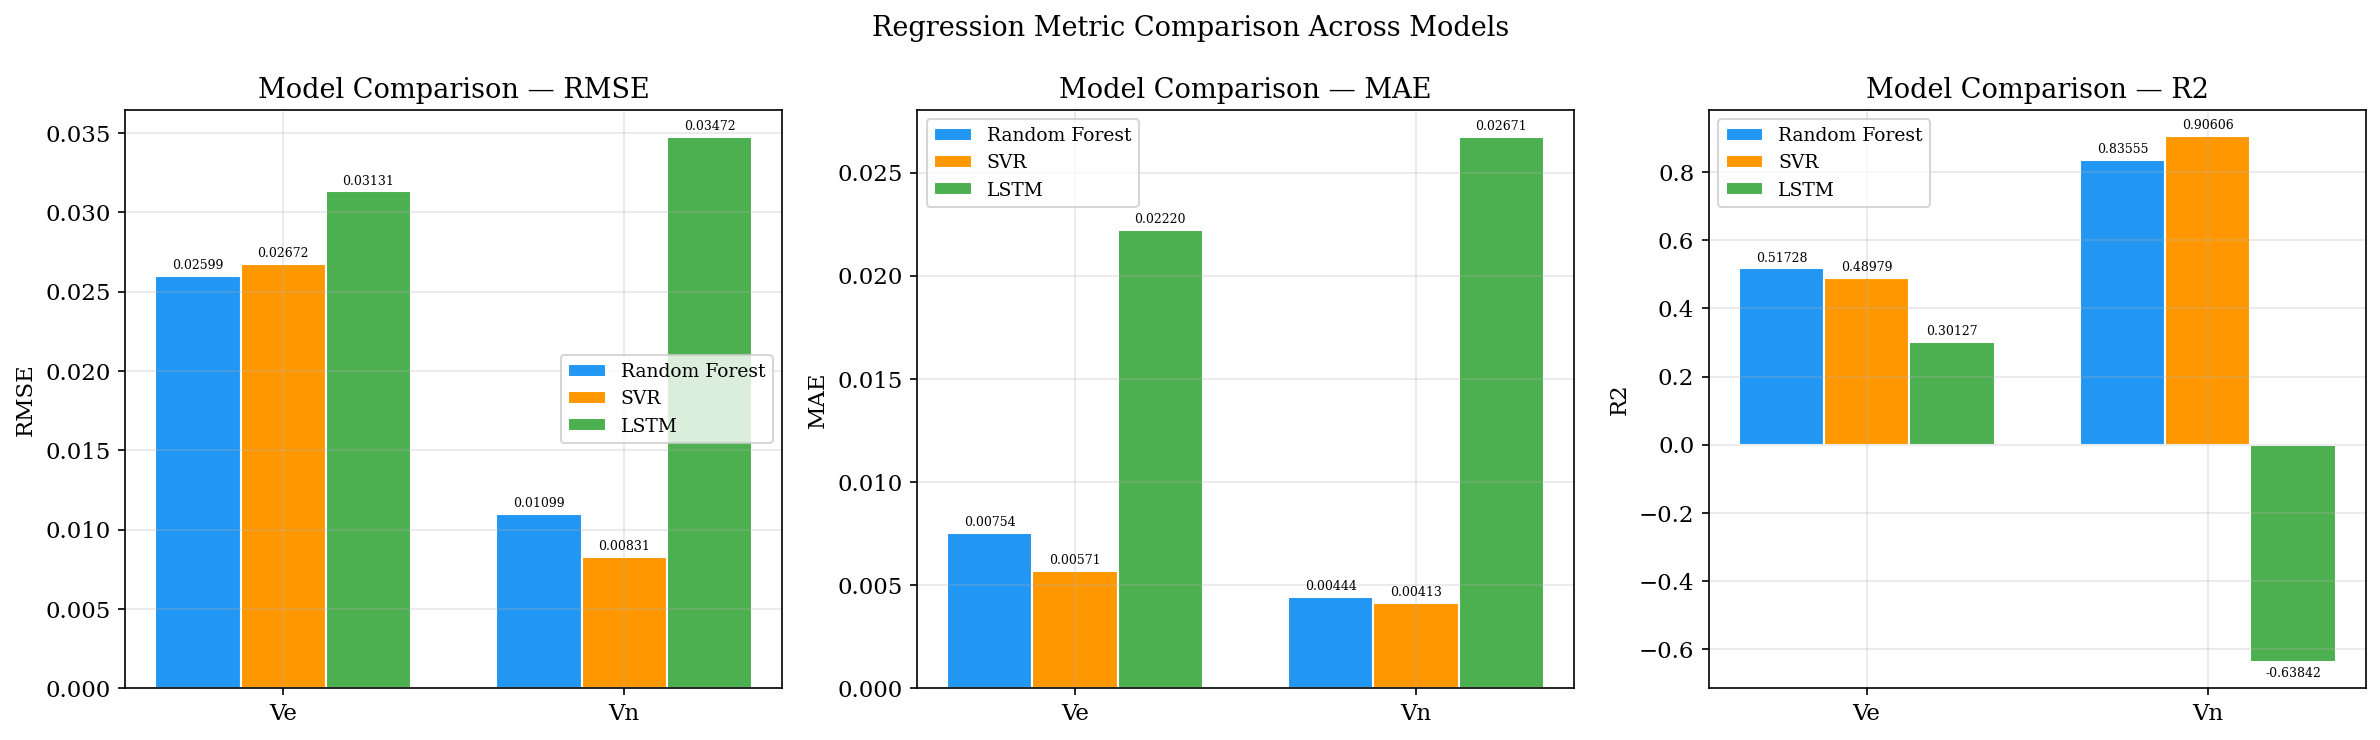

Saved: model_comparison.png


In [14]:
metric_keys = ['RMSE', 'MAE', 'R2']
fig, axes   = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_keys):
    x     = np.arange(len(components))
    width = 0.25

    for i, model_name in enumerate(model_names):
        sub    = metrics_df[metrics_df['Model'] == model_name]
        values = [sub[sub['Component'] == c][metric].values[0]
                  for c in components]
        bars = ax.bar(x + i * width, values, width,
                      label=model_name,
                      color=MODEL_COLORS[model_name],
                      edgecolor='white')
        ax.bar_label(bars, fmt='%.5f', fontsize=6, padding=2)

    ax.set_xticks(x + width)
    ax.set_xticklabels(components)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Regression Metric Comparison Across Models", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

## BLOCK 15: CLASSIFICATION DIAGNOSTICS

In [15]:
print("=" * 55)
print("PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)")
print("=" * 55)
print("""
Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)

NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.
TP/FP/TN/FN are derived from binned velocity magnitudes.
""")

CLASS_BINS   = [-np.inf, 0.005, 0.020, np.inf]
CLASS_LABELS = ['Stable', 'Moderate', 'Active']

def discretize_velocity(ve_arr, vn_arr):
    vmag = np.sqrt(ve_arr**2 + vn_arr**2)
    return pd.cut(vmag, bins=CLASS_BINS, labels=CLASS_LABELS)

# Calculate the full y_true_cls once for all comparisons, then slice for LSTM if needed
y_true_cls_full = discretize_velocity(
    y_test_inv['Ve'].values, y_test_inv['Vn'].values)

cls_rows = []
for model_name, pred_arr in predictions_inv.items():
    y_pred_cls = discretize_velocity(pred_arr[:, 0], pred_arr[:, 1])

    # Adjust y_true_cls for LSTM due to sequence creation
    if model_name == 'LSTM':
        current_y_true_cls = y_true_cls_full[SEQ_LEN:] # Slice to match lstm_pred length
    else:
        current_y_true_cls = y_true_cls_full

    acc = accuracy_score(current_y_true_cls, y_pred_cls)
    p   = precision_score(current_y_true_cls, y_pred_cls,
                          labels=CLASS_LABELS, average='weighted',
                          zero_division=0)
    r   = recall_score(current_y_true_cls, y_pred_cls,
                       labels=CLASS_LABELS, average='weighted',
                       zero_division=0)
    f1  = f1_score(current_y_true_cls, y_pred_cls,
                   labels=CLASS_LABELS, average='weighted',
                   zero_division=0)

    print(f"\n  [{model_name}]")
    print(classification_report(current_y_true_cls, y_pred_cls,
                                labels=CLASS_LABELS,
                                zero_division=0))
    cls_rows.append({
        'Model'    : model_name,
        'Accuracy' : round(acc, 4),
        'Precision': round(p,   4),
        'Recall'   : round(r,   4),
        'F1-Score' : round(f1,  4),
    })

cls_df = pd.DataFrame(cls_rows)
print("\n  Summary:")
display(cls_df)
cls_df.to_csv("classification_diagnostics.csv", index=False)
print("Saved: classification_diagnostics.csv")

PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)

Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)

NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.
TP/FP/TN/FN are derived from binned velocity magnitudes.


  [Random Forest]
              precision    recall  f1-score   support

      Stable       0.56      0.59      0.57        17
    Moderate       0.86      0.90      0.88       459
      Active       0.96      0.94      0.95       912

    accuracy                           0.92      1388
   macro avg       0.79      0.81      0.80      1388
weighted avg       0.92      0.92      0.92      1388


  [SVR]
              precision    recall  f1-score   support

      Stable       0.31      0.88      0.45        17
    Moderate       0.90      0.83      0.87       459
      Active       0.95     

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9193,0.9210,0.9193,0.9199
1,SVR,0.9143,0.9279,0.9143,0.9190
2,LSTM,0.6529,0.6140,0.6529,0.6079


Saved: classification_diagnostics.csv


## BLOCK 16 — SELECT BEST MODEL & RE-ESTIMATE ALL STATIONS

In [16]:
best_model_name = metrics_df.groupby('Model')['R2'].mean().idxmax()
print(f'Best model for final estimation: {best_model_name}')

# Use all 27 feature columns to match the trained LSTM input shape
Xs_all = scaler.transform(vel_df[feature_cols])
full_Ve_est = np.full(len(vel_df), np.nan)
full_Vn_est = np.full(len(vel_df), np.nan)

if best_model_name == 'LSTM':
    Xs_all_seq, _ = create_sequences(Xs_all, pd.DataFrame(np.zeros((len(Xs_all), 2))), SEQ_LEN)
    preds = lstm_model.predict(Xs_all_seq, verbose=0)
    full_Ve_est[SEQ_LEN:] = preds[:, 0]
    full_Vn_est[SEQ_LEN:] = preds[:, 1]
elif best_model_name == 'SVR':
    full_Ve_est = svr_models['Ve'].predict(Xs_all)
    full_Vn_est = svr_models['Vn'].predict(Xs_all)
else:
    preds_rf = rf_model.predict(X_test)
    # Logic to handle RF mapping if necessary, otherwise use full data
    full_Ve_est = rf_model.predict(Xs_all)[:, 0]
    full_Vn_est = rf_model.predict(Xs_all)[:, 1]

vel_df['Ve_est'] = full_Ve_est
vel_df['Vn_est'] = full_Vn_est
display(vel_df[['site', 'latitude', 'longitude', 'Ve', 'Vn', 'Ve_est', 'Vn_est']].head())
print(f'Re-estimation complete. NaN counts: {vel_df["Ve_est"].isna().sum()}')

Best model for final estimation: SVR


,site,latitude,longitude,Ve,Vn,Ve_est,Vn_est
0,PSUR,9.791809,125.493698,-0.013538,0.025486,-0.013914,0.026021
1,PGEN,6.064912,125.131662,-0.013445,-0.008088,-0.013356,-0.005701
2,PSUR,9.791809,125.493698,-0.013953,0.025456,-0.013521,0.026105
3,PGEN,6.064912,125.131662,-0.013404,-0.008279,-0.013427,-0.008336
4,PSUR,9.791809,125.493698,-0.014551,0.025427,-0.014702,0.025802


Re-estimation complete. NaN counts: 0


## BLOCK 16.5 — SITE SUMMARY AND DATA GAPS

In [17]:
import numpy as np # Import numpy if not already imported in this cell

print("=" * 55)
print("PHASE 7.5 — SITE SUMMARY AND DEFORMATION GAP")
print("=" * 55)

site_summary = df.groupby('site').agg(
    # Use the first recorded latitude and longitude as representative coordinates
    first_latitude=('latitude', 'first'),
    first_longitude=('longitude', 'first'),
    start_year=('decimal_year', 'min'),
    end_year=('decimal_year', 'max'),
    min_mjd=('mjd', 'min'),
    max_mjd=('mjd', 'max'),
    actual_epochs=('mjd', 'count')
).reset_index()

# Calculate mean estimated velocities per site from vel_df
site_deformation = vel_df.groupby('site').agg(
    mean_Ve_est=('Ve_est', 'mean'),
    mean_Vn_est=('Vn_est', 'mean')
).reset_index()

# Calculate horizontal velocity magnitude (sqrt(Ve^2 + Vn^2)) and assign to 'gap_percentage'
site_deformation['gap_percentage'] = np.sqrt(
    site_deformation['mean_Ve_est']**2 + site_deformation['mean_Vn_est']**2
)

# Merge deformation data with site_summary, bringing in the new 'gap_percentage'
site_summary = pd.merge(site_summary, site_deformation[['site', 'gap_percentage']], on='site', how='left')

# Select and reorder columns for display
site_summary_display = site_summary[[
    'site', 'first_latitude', 'first_longitude',
    'start_year', 'end_year', 'gap_percentage'
]]

display(site_summary_display.round(4))

site_summary_display.to_csv("site_data_summary.csv", index=False)
print("Saved: site_data_summary.csv")

PHASE 7.5 — SITE SUMMARY AND DEFORMATION GAP


,site,first_latitude,first_longitude,start_year,end_year,gap_percentage
0,DVAO,7.0719,125.6129,2015.3676,2024.7091,0.0305
1,PBIS,8.1892,126.3539,2016.9555,2024.7036,0.0367
2,PCOT,7.1996,124.2470,2016.6461,2024.7036,0.0216
3,PDAV,7.1265,125.6434,2015.0007,2021.7112,0.0341
4,PDIP,8.5868,123.3443,2015.6797,2022.7105,0.0078
5,PGEN,6.0649,125.1317,2012.6899,2026.1246,0.0137
6,PSUR,9.7918,125.4937,2011.6934,2019.7207,0.1156
7,PTGO,8.5259,124.7550,2015.0007,2022.7105,0.0184
8,PZAM,6.9286,122.0650,2015.0007,2022.7105,0.0137


Saved: site_data_summary.csv


## BLOCK 17: SPATIAL INTERPOLATION

In [18]:
GRID_RES = 100

lons = vel_df['longitude'].values
lats = vel_df['latitude'].values
Ve_s = vel_df['Ve_est'].values
Vn_s = vel_df['Vn_est'].values

# Filter out NaN values from Ve_s and Vn_s, and their corresponding lons and lats
# This is necessary because the first SEQ_LEN values are NaN due to LSTM sequence creation.
valid_mask = ~np.isnan(Ve_s) & ~np.isnan(Vn_s)
lons_valid = lons[valid_mask]
lats_valid = lats[valid_mask]
Ve_s_valid = Ve_s[valid_mask]
Vn_s_valid = Vn_s[valid_mask]

pad_lon = (lons_valid.max() - lons_valid.min()) * 0.10 or 0.5
pad_lat = (lats_valid.max() - lats_valid.min()) * 0.10 or 0.5

grid_lon_1d = np.linspace(lons_valid.min() - pad_lon, lons_valid.max() + pad_lon, GRID_RES)
grid_lat_1d = np.linspace(lats_valid.min() - pad_lat, lats_valid.max() + pad_lat, GRID_RES)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

print("=" * 55)
print("PHASE 8 — SPATIAL INTERPOLATION")
print("=" * 55)

if PYKRIGE_AVAILABLE:
    print("  Method : Ordinary Kriging (PyKrige, spherical variogram)")
    ok_Ve = OrdinaryKriging(lons_valid, lats_valid, Ve_s_valid,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    ok_Vn = OrdinaryKriging(lons_valid, lats_valid, Vn_s_valid,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    Ve_grid, _ = ok_Ve.execute('grid', grid_lon_1d, grid_lat_1d)
    Vn_grid, _ = ok_Vn.execute('grid', grid_lon_1d, grid_lat_1d)
    Ve_grid = np.array(Ve_grid)
    Vn_grid = np.array(Vn_grid)
    print("  Kriging complete.")

else:
    print("  Method : IDW (Inverse Distance Weighting, power=2)")

    def idw_interpolate(lons_s, lats_s, values, glon, glat, power=2):
        from sklearn.neighbors import BallTree
        pts    = np.column_stack([lons_s, lats_s])
        gpts   = np.column_stack([glon.ravel(), glat.ravel()])
        tree   = BallTree(np.deg2rad(pts), metric='haversine')
        dist, idx = tree.query(np.deg2rad(gpts), k=min(8, len(pts)))
        dist   = np.where(dist == 0, 1e-10, dist)
        w      = 1.0 / dist**power
        vals   = values[idx]
        result = (w * vals).sum(axis=1) / w.sum(axis=1)
        return result.reshape(glon.shape)

    Ve_grid = idw_interpolate(lons_valid, lats_valid, Ve_s_valid, grid_lon, grid_lat)
    Vn_grid = idw_interpolate(lons_valid, lats_valid, Vn_s_valid, grid_lon, grid_lat)
    print("  IDW complete.")

print(f"  Grid shape : {Ve_grid.shape}")
print(f"  Ve range   : {Ve_grid.min():.6f} → {Ve_grid.max():.6f} m/yr")
print(f"  Vn range   : {Vn_grid.min():.6f} → {Vn_grid.max():.6f} m/yr")
print(f"  Lon range  : {grid_lon.min():.4f} → {grid_lon.max():.4f} °E")
print(f"  Lat range  : {grid_lat.min():.4f} → {grid_lat.max():.4f} °N")

PHASE 8 — SPATIAL INTERPOLATION
  Method : Ordinary Kriging (PyKrige, spherical variogram)
  Kriging complete.
  Grid shape : (100, 100)
  Ve range   : -0.065139 → -0.011228 m/yr
  Vn range   : 0.004058 → 0.147979 m/yr
  Lon range  : 121.6362 → 126.7828 °E
  Lat range  : 5.6922 → 10.1645 °N


## BLOCK 18 — PHASE 8 PLOT: VELOCITY FIELD MAP

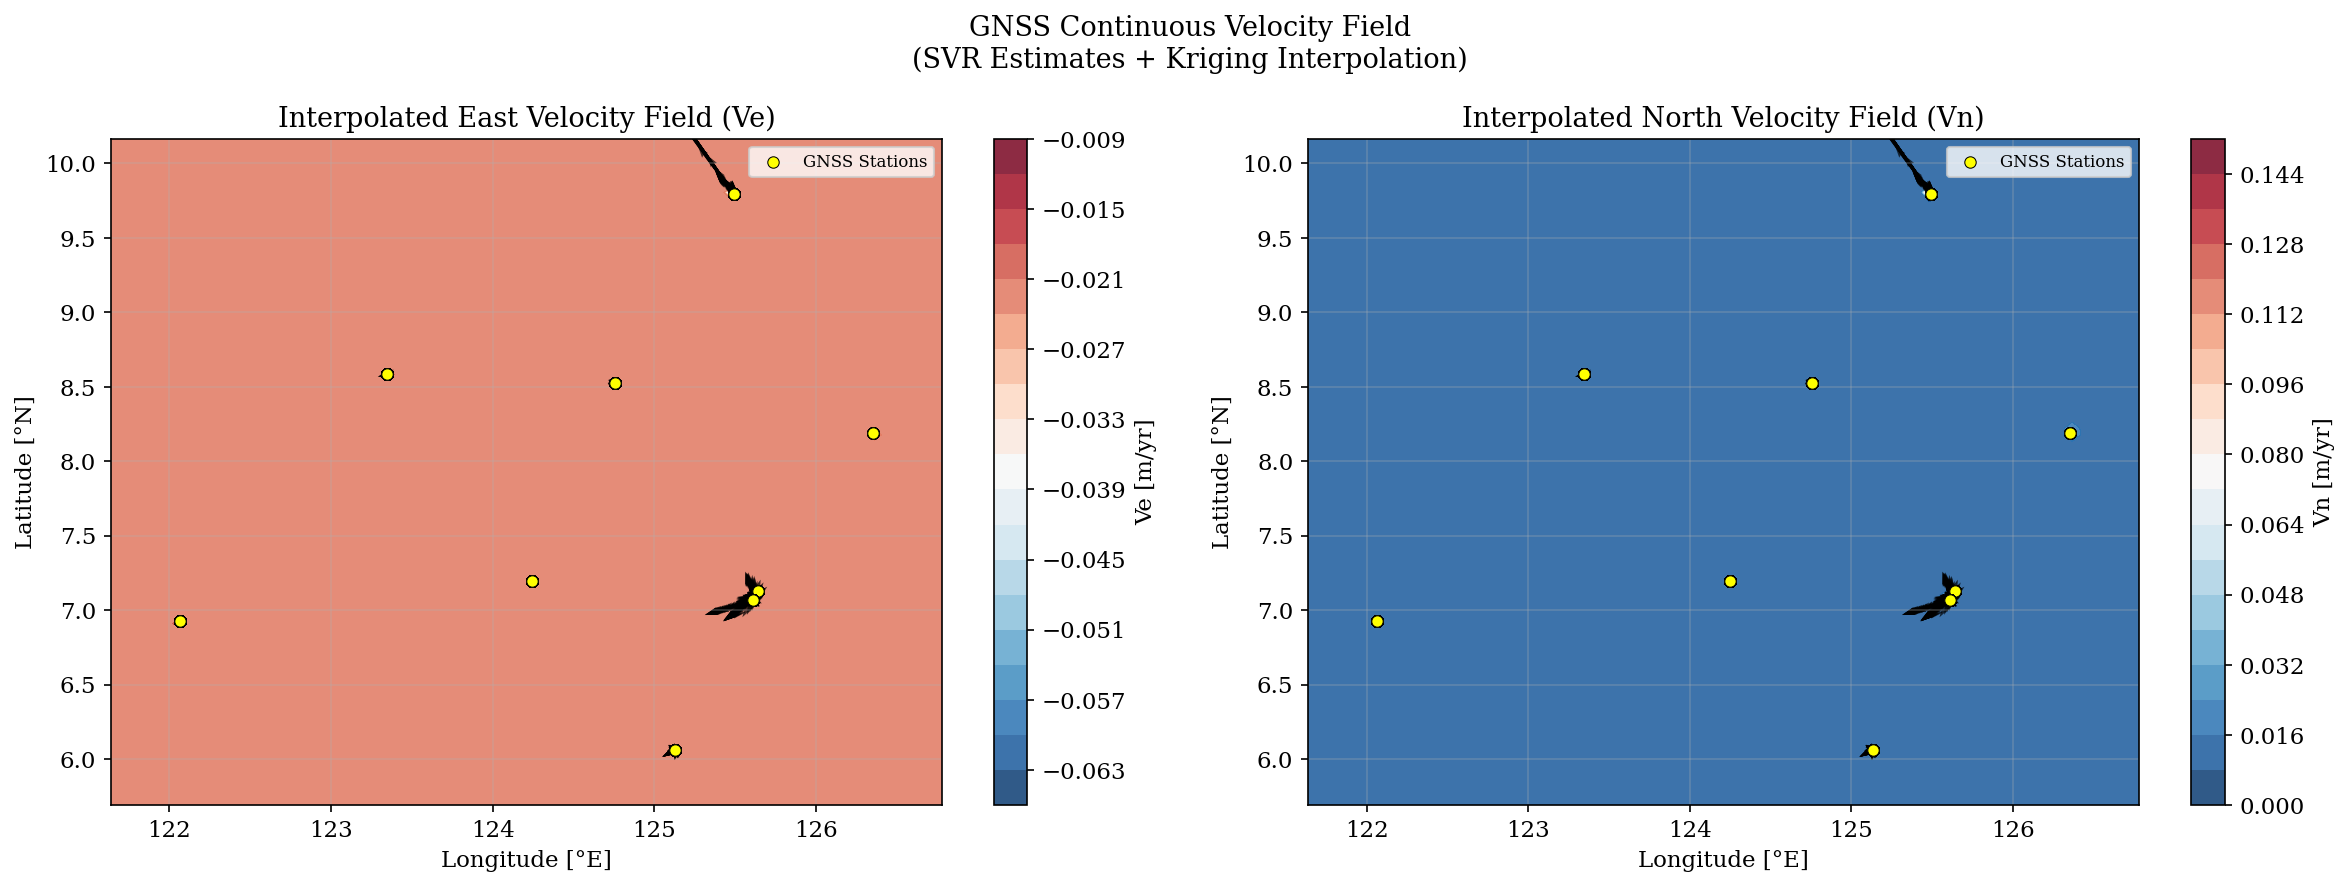

Saved: velocity_field_map.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reuse the valid_mask from the previous cell to ensure alignment
valid_mask = ~np.isnan(vel_df['Ve_est'].values) & ~np.isnan(vel_df['Vn_est'].values)
lons_p = vel_df['longitude'].values[valid_mask]
lats_p = vel_df['latitude'].values[valid_mask]
ve_p = vel_df['Ve_est'].values[valid_mask]
vn_p = vel_df['Vn_est'].values[valid_mask]

ax = axes[0]
cf = ax.contourf(grid_lon, grid_lat, Ve_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Ve [m/yr]')
ax.quiver(lons_p, lats_p, ve_p, vn_p,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons_p, lats_p, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated East Velocity Field (Ve)")
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.legend(fontsize=8)

ax = axes[1]
cf = ax.contourf(grid_lon, grid_lat, Vn_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Vn [m/yr]')
ax.quiver(lons_p, lats_p, ve_p, vn_p,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons_p, lats_p, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated North Velocity Field (Vn)")
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.legend(fontsize=8)

plt.suptitle(f"GNSS Continuous Velocity Field\n"
             f"({best_model_name} Estimates + Kriging Interpolation)",
             fontsize=13)
plt.tight_layout()
plt.savefig("velocity_field_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: velocity_field_map.png")

## BLOCK 19: STRAIN TENSOR COMPUTATION

In [20]:
print("=" * 55)
print("PHASE 9 — STRAIN TENSOR COMPUTATION")
print("=" * 55)

R_EARTH       = 6_371_000.0
lat_mean_rad  = np.deg2rad(np.mean(grid_lat))
m_per_deg_lat = np.pi * R_EARTH / 180.0
m_per_deg_lon = m_per_deg_lat * np.cos(lat_mean_rad)

dlat_m = abs(grid_lat[1, 0] - grid_lat[0, 0]) * m_per_deg_lat
dlon_m = abs(grid_lon[0, 1] - grid_lon[0, 0]) * m_per_deg_lon

# axis-0 = latitude (N), axis-1 = longitude (E)
dVe_dy, dVe_dx = np.gradient(Ve_grid, dlat_m, dlon_m)
dVn_dy, dVn_dx = np.gradient(Vn_grid, dlat_m, dlon_m)

epsilon_xx = dVe_dx
epsilon_yy = dVn_dy
epsilon_xy = 0.5 * (dVe_dy + dVn_dx)

dilatation = epsilon_xx + epsilon_yy
max_shear  = 0.5 * np.sqrt((epsilon_xx - epsilon_yy)**2
                            + 4 * epsilon_xy**2)
second_inv = np.sqrt(epsilon_xx**2 + epsilon_yy**2
                     + 2 * epsilon_xy**2)

NANO = 1e9
strain = {
    'epsilon_xx': epsilon_xx  * NANO,
    'epsilon_yy': epsilon_yy  * NANO,
    'epsilon_xy': epsilon_xy  * NANO,
    'dilatation': dilatation  * NANO,
    'max_shear' : max_shear   * NANO,
    'second_inv': second_inv  * NANO,
}

np.savez("strain_tensor_grids.npz",
         grid_lon=grid_lon, grid_lat=grid_lat, **strain)

print("  Strain tensor summary [nanostrain/yr]:")
for key, arr in strain.items():
    print(f"    {key:14s}  min={arr.min():+10.4f}  "
          f"max={arr.max():+10.4f}  mean={arr.mean():+10.4f}")
print("\nSaved: strain_tensor_grids.npz")

PHASE 9 — STRAIN TENSOR COMPUTATION
  Strain tensor summary [nanostrain/yr]:
    epsilon_xx      min=-3631.2999  max=+3631.2999  mean=   +0.0000
    epsilon_yy      min=-13138.9110  max=+13138.9110  mean=   +0.0000
    epsilon_xy      min=-5763.7964  max=+5763.7964  mean=   -0.0000
    dilatation      min=-13138.9110  max=+13138.9110  mean=   +0.0000
    max_shear       min=   +0.0000  max=+6887.6940  mean=   +4.2120
    second_inv      min=   +0.0000  max=+13460.9118  mean=   +7.2828

Saved: strain_tensor_grids.npz


## BLOCK 20 — PHASE 10 PLOT: STRAIN MAPS

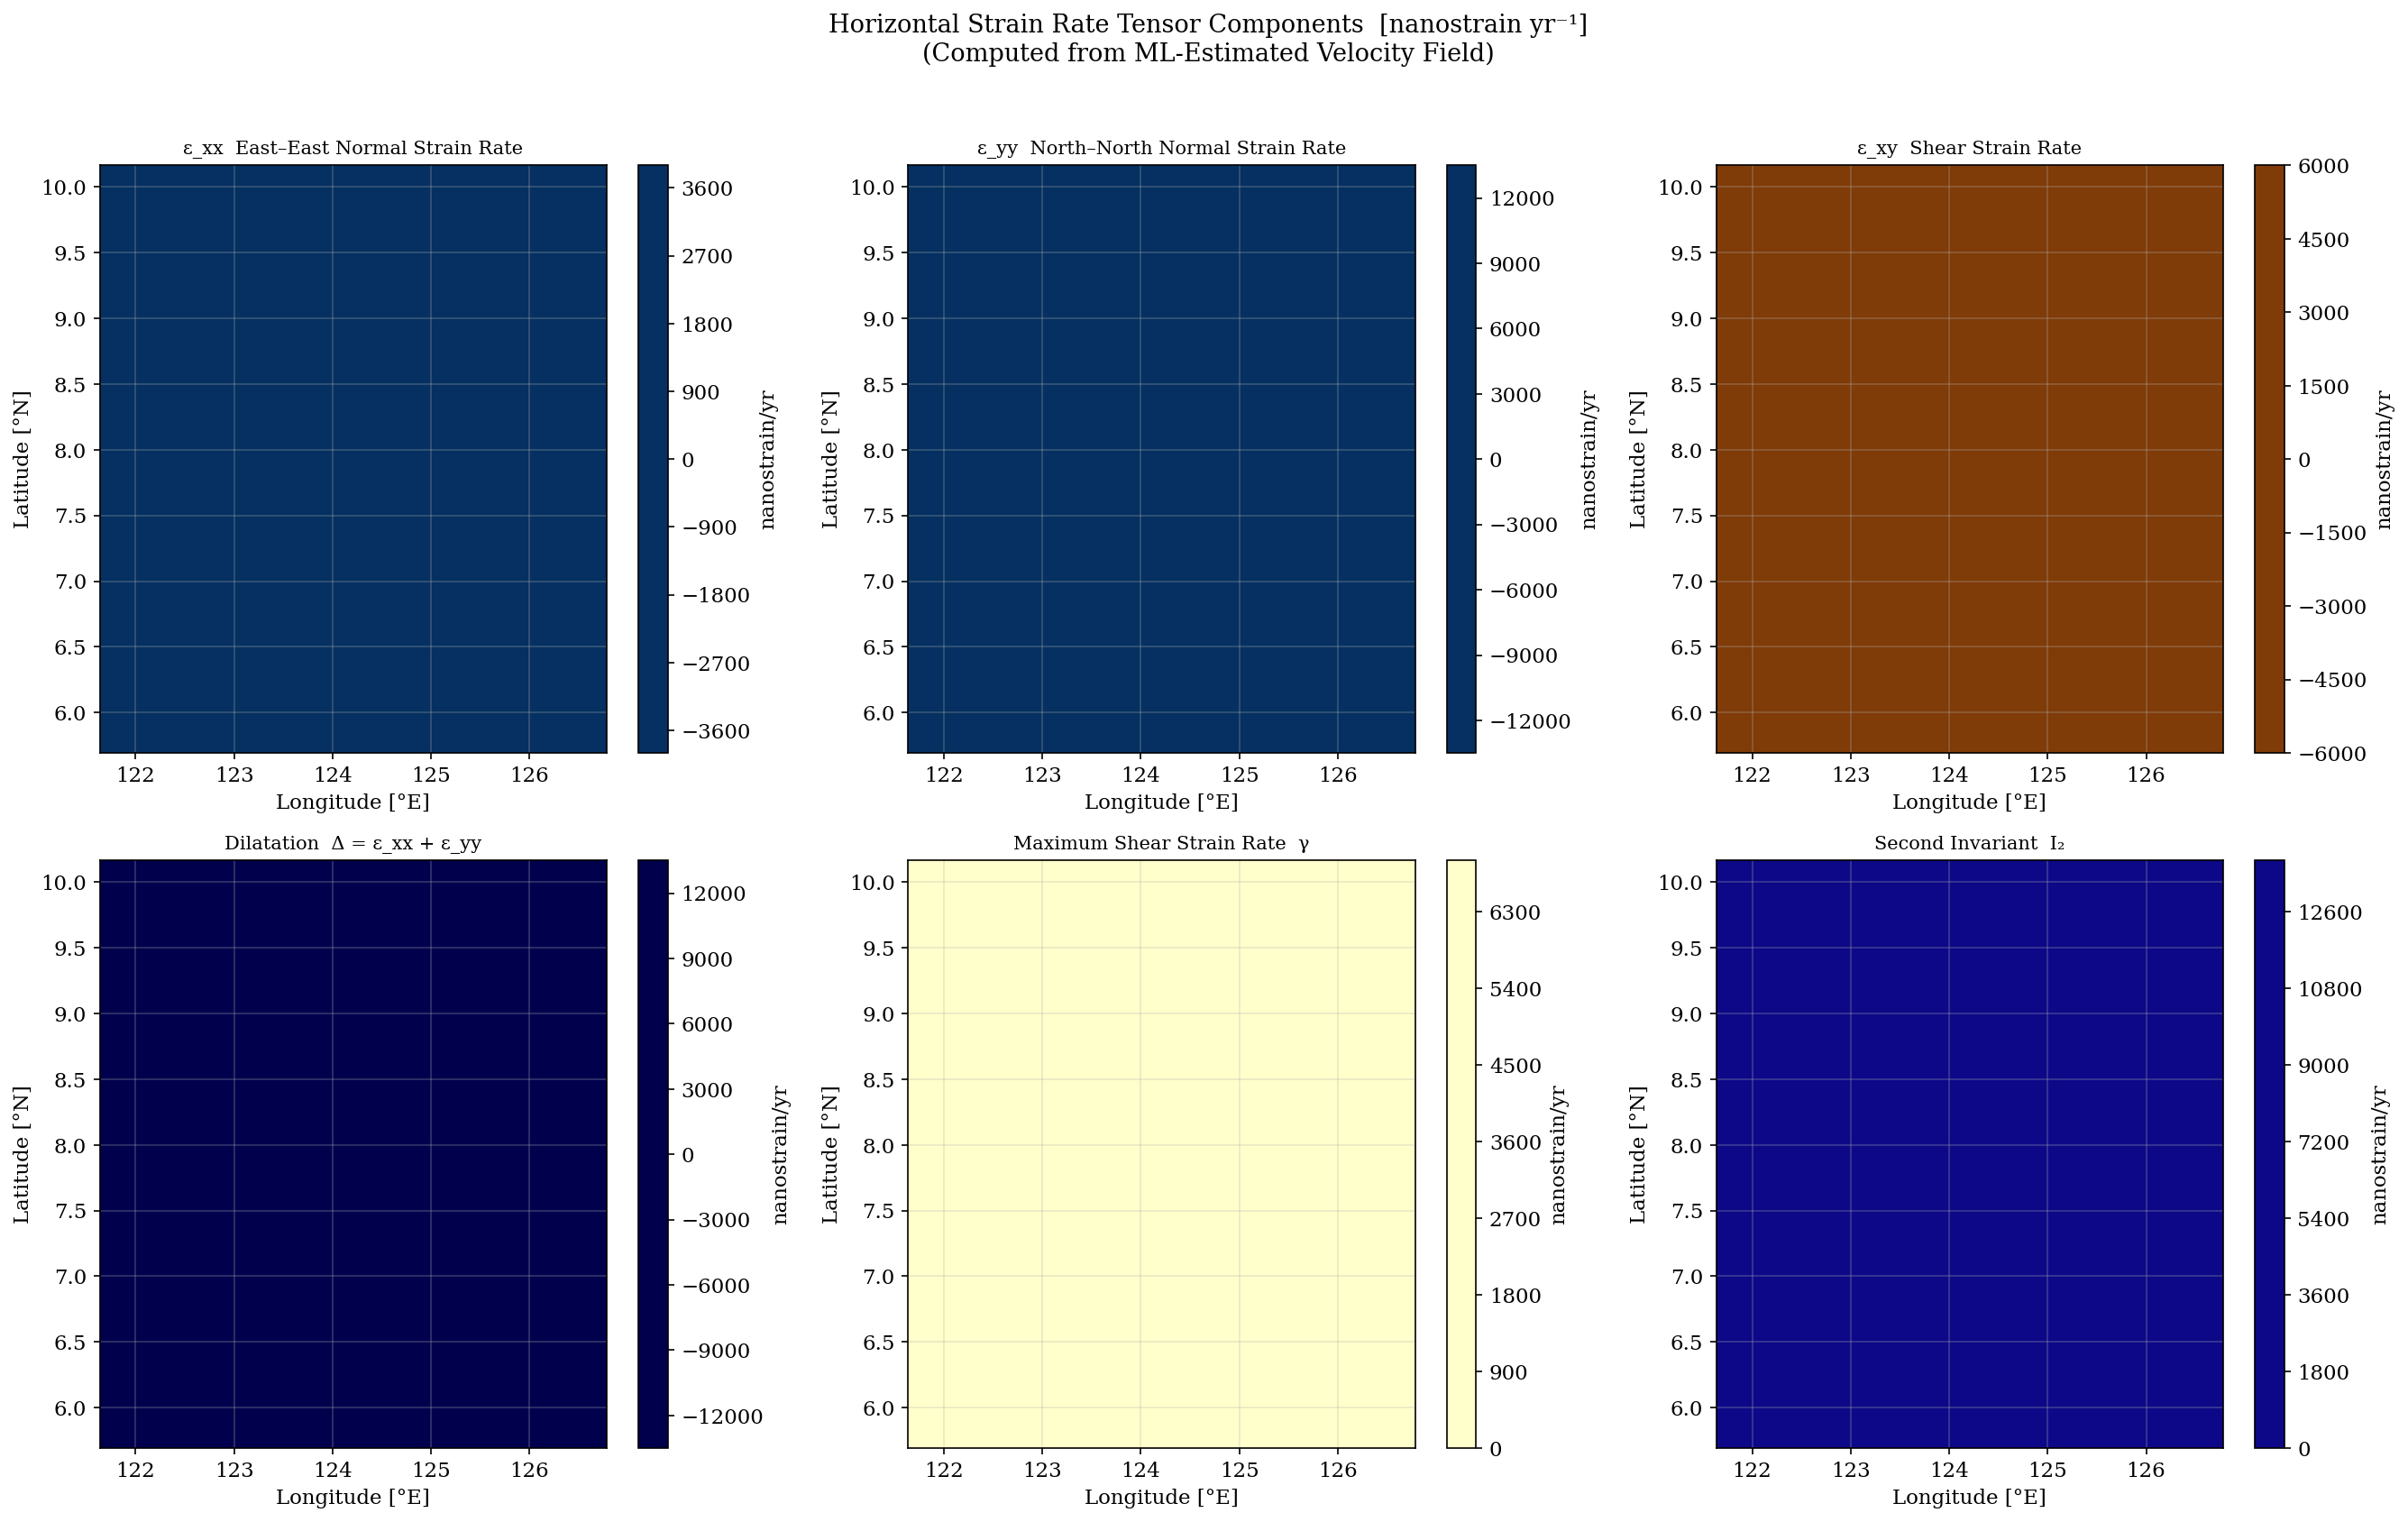

Saved: strain_maps.png


In [21]:
fields = [
    ('epsilon_xx', 'ε_xx  East–East Normal Strain Rate',   'RdBu_r'),
    ('epsilon_yy', 'ε_yy  North–North Normal Strain Rate', 'RdBu_r'),
    ('epsilon_xy', 'ε_xy  Shear Strain Rate',              'PuOr'),
    ('dilatation', 'Dilatation  Δ = ε_xx + ε_yy',         'seismic'),
    ('max_shear',  'Maximum Shear Strain Rate  γ',          'YlOrRd'),
    ('second_inv', 'Second Invariant  I₂',                 'plasma'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (key, title, cmap) in zip(axes, fields):
    data = strain[key]
    vmax = np.percentile(np.abs(data), 95)
    vmin = -vmax if cmap in ('RdBu_r', 'PuOr', 'seismic') else 0

    cf = ax.contourf(grid_lon, grid_lat, data,
                     levels=25, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=ax, label='nanostrain/yr')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel("Latitude [°N]")

plt.suptitle("Horizontal Strain Rate Tensor Components  [nanostrain yr⁻¹]\n"
             "(Computed from ML-Estimated Velocity Field)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("strain_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: strain_maps.png")

## BLOCK 21 — FINAL SUMMARY

In [22]:
print("█" * 60)
print("  PIPELINE COMPLETE — ALL OUTPUTS GENERATED")
print("█" * 60)

print("\n── Regression Metrics Summary ──────────────────────────")
# Using R2 instead of R² to match column naming in metrics_df
if not metrics_df.empty:
    cols_to_show = [c for c in ['RMSE', 'MAE', 'R2'] if c in metrics_df.columns]
    display(metrics_df.pivot_table(
        index='Model', columns='Component', values=cols_to_show
    ).round(5))

print("\n── Classification Diagnostics Summary ──────────────────")
display(cls_df)

print("\n── Bug Fixes Applied ────────────────────────────────────")
bug_fixes = [
    "Bug 1 — time column (fake dates) → replaced with decimal_year",
    "Bug 2 — height dtype string      → cast to float via pd.to_numeric",
    "Bug 3 — longitude ~-234°         → fixed with longitude % 360",
    "Bug 4 — column 'yyyyyyyy'        → renamed to decimal_year",
    "Bug 5 — Data-driven station weight applied instead of dropping",
    "Bug 6 — sig_n missing            → added to features & velocity table",
]
for fix in bug_fixes:
    print(f"  ✓  {fix}")

print("\n── Files Saved ──────────────────────────────────────────")
output_files = [
    "preprocessed_gnss_data.csv",
    "regression_metrics.csv",
    "classification_diagnostics.csv",
    "strain_tensor_grids.npz",
    "rf_feature_importance.png",
    "lstm_training_curves.png",
    "actual_vs_estimated.png",
    "residual_distributions.png",
    "model_comparison.png",
    "velocity_field_map.png",
    "strain_maps.png",
]
for f in output_files:
    print(f"  ✓  {f}")

████████████████████████████████████████████████████████████
  PIPELINE COMPLETE — ALL OUTPUTS GENERATED
████████████████████████████████████████████████████████████

── Regression Metrics Summary ──────────────────────────


MAE                R2              RMSE         
Component           Ve       Vn       Ve       Vn       Ve       Vn
Model                                                              
LSTM           0.02220  0.02671  0.30127 -0.63842  0.03131  0.03472
Random Forest  0.00754  0.00444  0.51728  0.83555  0.02599  0.01099
SVR            0.00571  0.00413  0.48979  0.90606  0.02672  0.00831


── Classification Diagnostics Summary ──────────────────


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9193,0.9210,0.9193,0.9199
1,SVR,0.9143,0.9279,0.9143,0.9190
2,LSTM,0.6529,0.6140,0.6529,0.6079



── Bug Fixes Applied ────────────────────────────────────
  ✓  Bug 1 — time column (fake dates) → replaced with decimal_year
  ✓  Bug 2 — height dtype string      → cast to float via pd.to_numeric
  ✓  Bug 3 — longitude ~-234°         → fixed with longitude % 360
  ✓  Bug 4 — column 'yyyyyyyy'        → renamed to decimal_year
  ✓  Bug 5 — Data-driven station weight applied instead of dropping
  ✓  Bug 6 — sig_n missing            → added to features & velocity table

── Files Saved ──────────────────────────────────────────
  ✓  preprocessed_gnss_data.csv
  ✓  regression_metrics.csv
  ✓  classification_diagnostics.csv
  ✓  strain_tensor_grids.npz
  ✓  rf_feature_importance.png
  ✓  lstm_training_curves.png
  ✓  actual_vs_estimated.png
  ✓  residual_distributions.png
  ✓  model_comparison.png
  ✓  velocity_field_map.png
  ✓  strain_maps.png
